# Healthcare Diabetes Analytics - Machine Learning Dataset Analysis

**Project:** Healthcare Database Analytics (SQL - CPSC 500-13 Final Project)  
**Group:** 1  
**Date:** December 6, 2025  
**Database:** healthcare_diabetes  

---

## Objective
This notebook demonstrates connecting to the healthcare_diabetes MySQL database,  
extracting ML-ready datasets, and performing basic analytics with visualizations.

---

## Requirements Met
✅ Connect database to Python notebook  
✅ Execute complex queries  
✅ Demonstrate basic analytics  
✅ Create visualizations  
✅ Extract ML datasets  

## 1. Setup and Database Connection

In [1]:
# Import required libraries
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")
print(f"Analysis timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Libraries imported successfully
Analysis timestamp: 2025-12-09 00:17:19


In [2]:
# Database connection
# NOTE: Update these credentials for your MySQL installation
try:
    conn = mysql.connector.connect(
        host='localhost',
        user='root',              # UPDATE THIS
        password='', # PLEASE UPDATE THIS!!!!!!
        database='healthcare_diabetes'
    )
    
    print("✓ Successfully connected to healthcare_diabetes database")
    print(f"Connection ID: {conn.connection_id}")
    print(f"Database: {conn.database}")
    print(f"User: {conn.user}")
    
except mysql.connector.Error as err:
    print(f"✗ Connection failed: {err}")
    print("Please update host, user, and password in the connection parameters")

✓ Successfully connected to healthcare_diabetes database
Connection ID: 74
Database: healthcare_diabetes
User: root


## 2. Extract Classification Dataset (Complex Query 1)

This query extracts a **classification dataset** for predicting 30-day hospital readmissions.  
Uses patient demographics, encounter history, and clinical features.

In [3]:
# Complex Query 1: Patient Risk Profiling (Classification ML)
query_classification = """
-- ════════════════════════════════════════════════════════════════════════════
-- COMPLEX QUERY 1: Patient Risk Profiling (Corrected for 3NF Schema)
-- ════════════════════════════════════════════════════════════════════════════
WITH patient_encounters AS (
    SELECT 
        e.patient_id,
        COUNT(DISTINCT e.encounter_id) AS total_encounters,
        AVG(e.time_in_hospital) AS avg_los,
        -- Get the most recent age recorded for the patient
        MAX(e.encounter_age) as latest_age,
        SUM(CASE WHEN o.readmitted_category IN ('<30', '>30') THEN 1 ELSE 0 END) AS total_readmissions,
        SUM(CASE WHEN o.readmitted_category = '<30' THEN 1 ELSE 0 END) AS early_readmissions,
        -- We calculate medication/diagnosis counts from junction tables instead of raw columns
        COUNT(DISTINCT ed.drug_id) AS unique_drugs,
        COUNT(DISTINCT ediag.diagnosis_code_id) AS unique_diagnoses,
        SUM(e.number_emergency) as total_emergency_visits,
        SUM(e.number_inpatient) as total_inpatient_visits
    FROM encounters e
    LEFT JOIN outcomes o ON e.encounter_id = o.encounter_id
    LEFT JOIN encounter_drugs ed ON e.encounter_id = ed.encounter_id
    LEFT JOIN encounter_diagnoses ediag ON e.encounter_id = ediag.encounter_id
    GROUP BY e.patient_id
)
SELECT 
    p.patient_id,
    CASE WHEN p.race IS NULL THEN 'Unknown' ELSE p.race END AS race,
    p.gender,
    pe.latest_age as age,
    JSON_UNQUOTE(JSON_EXTRACT(p.risk_factors, '$.diabetes')) AS has_diabetes,
    pe.total_encounters,
    ROUND(pe.avg_los, 2) AS avg_los,
    pe.total_readmissions,
    pe.early_readmissions,
    pe.unique_drugs,
    pe.unique_diagnoses,
    pe.total_emergency_visits,
    pe.total_inpatient_visits,
    CASE WHEN pe.early_readmissions > 0 THEN 1 ELSE 0 END AS readmission_30d_binary,
    CASE 
        WHEN pe.early_readmissions >= 2 THEN 'Very High Risk'
        WHEN pe.early_readmissions = 1 THEN 'High Risk'
        WHEN pe.total_encounters >= 3 THEN 'Medium Risk'
        ELSE 'Low Risk'
    END AS risk_category
FROM patients p
JOIN patient_encounters pe ON p.patient_id = pe.patient_id
WHERE pe.total_encounters > 0
ORDER BY pe.early_readmissions DESC, pe.total_encounters DESC;
"""

# Execute query and load into DataFrame
df_classification = pd.read_sql(query_classification, conn)

print("✓ Classification dataset loaded successfully")
print(f"Dataset shape: {df_classification.shape}")
print(f"Patients: {len(df_classification)}")
print(f"Features: {df_classification.shape[1]}")
print(f"\nFirst 5 rows:")
df_classification.head()

✓ Classification dataset loaded successfully
Dataset shape: (245, 15)
Patients: 245
Features: 15

First 5 rows:


,patient_id,race,gender,age,has_diabetes,total_encounters,avg_los,total_readmissions,early_readmissions,unique_drugs,unique_diagnoses,total_emergency_visits,total_inpatient_visits,readmission_30d_binary,risk_category
0,60014520,Caucasian,Male,[70-80),true,1,7.0,9.0,9.0,3,3,0.0,0.0,1,Very High Risk
1,11617695,Caucasian,Male,[60-70),true,1,2.0,6.0,6.0,2,3,0.0,12.0,1,Very High Risk
2,110721573,Caucasian,Female,[50-60),true,1,3.0,6.0,6.0,2,3,0.0,0.0,1,Very High Risk
3,86407056,Caucasian,Male,[40-50),true,2,3.0,3.0,3.0,0,5,0.0,9.0,1,Very High Risk
4,2554614,Caucasian,Male,[60-70),true,1,4.0,3.0,3.0,1,3,0.0,6.0,1,Very High Risk


## 3. Descriptive Statistics

In [4]:
print("═" * 80)
print("DESCRIPTIVE STATISTICS - Classification Dataset")
print("═" * 80)

# Summary statistics for numeric features
print("\n1. NUMERIC FEATURES SUMMARY:")
print(df_classification.describe())

# Target variable distribution
print("\n2. TARGET VARIABLE DISTRIBUTION:")
print(df_classification['readmission_30d_binary'].value_counts())
readmission_rate = df_classification['readmission_30d_binary'].mean()
print(f"\nReadmission Rate: {readmission_rate:.2%}")

# Risk category distribution
print("\n3. RISK CATEGORY DISTRIBUTION:")
print(df_classification['risk_category'].value_counts())

# Demographic breakdown
print("\n4. RACE DISTRIBUTION:")
print(df_classification['race'].value_counts())

print("\n5. GENDER DISTRIBUTION:")
print(df_classification['gender'].value_counts())

print("\n6. AGE DISTRIBUTION:")
print(df_classification['age'].value_counts().sort_index())

════════════════════════════════════════════════════════════════════════════════
DESCRIPTIVE STATISTICS - Classification Dataset
════════════════════════════════════════════════════════════════════════════════

1. NUMERIC FEATURES SUMMARY:
         patient_id  total_encounters     avg_los  total_readmissions  \
count  2.450000e+02        245.000000  245.000000          245.000000   
mean   6.975964e+07          1.020408    4.677551            2.363265   
std    3.026140e+07          0.141681    2.752813            2.164040   
min    8.946900e+04          1.000000    1.000000            0.000000   
25%    5.382972e+07          1.000000    3.000000            0.000000   
50%    7.480403e+07          1.000000    4.000000            3.000000   
75%    9.150375e+07          1.000000    6.000000            3.000000   
max    1.148528e+08          2.000000   14.000000           12.000000   

       early_readmissions  unique_drugs  unique_diagnoses  \
count          245.000000    245.000000  

## 4. Data Visualizations

Create comprehensive visualizations to understand patterns in the data.

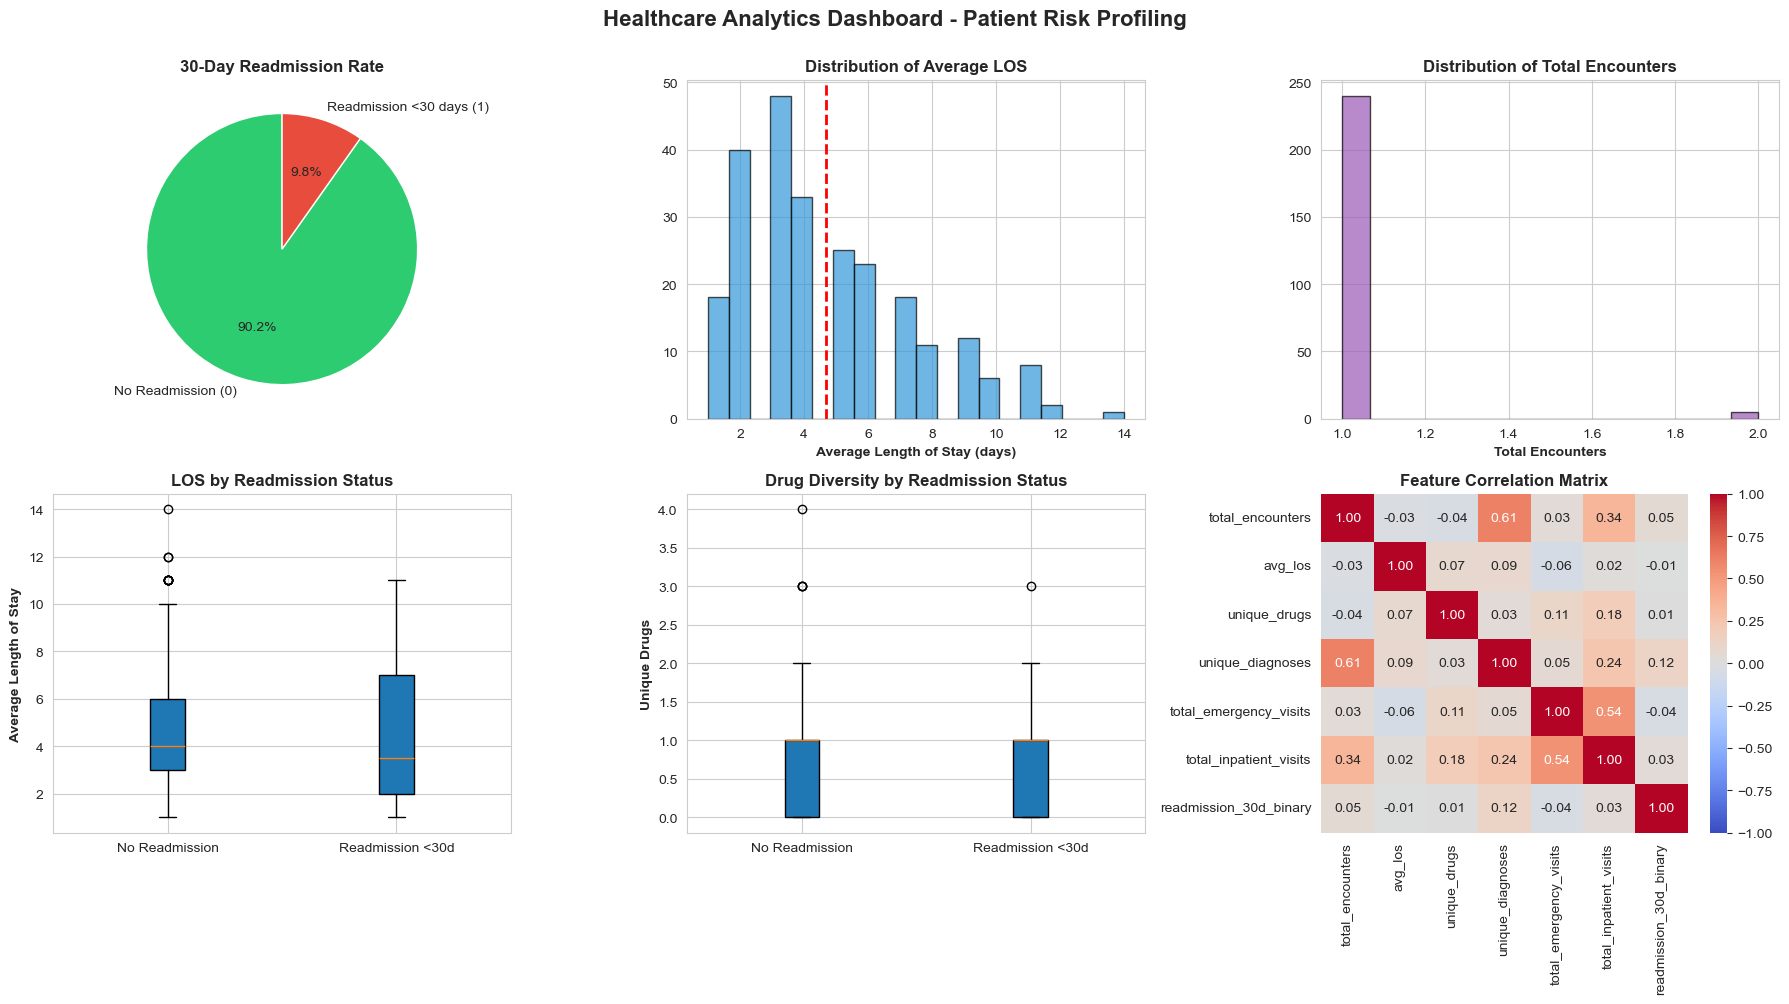


✓ Visualizations created successfully


In [5]:
# Create comprehensive visualization dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Healthcare Analytics Dashboard - Patient Risk Profiling', 
             fontsize=16, fontweight='bold', y=1.00)

# 1. Readmission Rate (Pie Chart)
readmit_counts = df_classification['readmission_30d_binary'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0, 0].pie(readmit_counts, 
               labels=['No Readmission (0)', 'Readmission <30 days (1)'],
               autopct='%1.1f%%', 
               startangle=90, 
               colors=colors,
               textprops={'fontsize': 10})
axes[0, 0].set_title('30-Day Readmission Rate', fontweight='bold')

# 2. Average Length of Stay (Histogram)
axes[0, 1].hist(df_classification['avg_los'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df_classification['avg_los'].mean(), color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Average Length of Stay (days)', fontweight='bold')
axes[0, 1].set_title('Distribution of Average LOS', fontweight='bold')

# 3. Total Encounters (Histogram)
axes[0, 2].hist(df_classification['total_encounters'], bins=15, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Total Encounters', fontweight='bold')
axes[0, 2].set_title('Distribution of Total Encounters', fontweight='bold')

# 4. LOS by Readmission (Box Plot)
readmit_no = df_classification[df_classification['readmission_30d_binary'] == 0]['avg_los']
readmit_yes = df_classification[df_classification['readmission_30d_binary'] == 1]['avg_los']
axes[1, 0].boxplot([readmit_no, readmit_yes], labels=['No Readmission', 'Readmission <30d'], patch_artist=True)
axes[1, 0].set_ylabel('Average Length of Stay', fontweight='bold')
axes[1, 0].set_title('LOS by Readmission Status', fontweight='bold')

# 5. Drug Diversity (Box Plot)
drugs_no = df_classification[df_classification['readmission_30d_binary'] == 0]['unique_drugs']
drugs_yes = df_classification[df_classification['readmission_30d_binary'] == 1]['unique_drugs']
axes[1, 1].boxplot([drugs_no, drugs_yes], labels=['No Readmission', 'Readmission <30d'], patch_artist=True)
axes[1, 1].set_ylabel('Unique Drugs', fontweight='bold')
axes[1, 1].set_title('Drug Diversity by Readmission Status', fontweight='bold')

# 6. Feature Correlation Heatmap (CORRECTED COLUMNS)
numeric_cols = ['total_encounters', 'avg_los', 'unique_drugs', 'unique_diagnoses', 
                'total_emergency_visits', 'total_inpatient_visits', 'readmission_30d_binary']
corr_matrix = df_classification[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2], vmin=-1, vmax=1)
axes[1, 2].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('healthcare_analytics_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations created successfully")

## 5. Key Insights Analysis

In [6]:
print("\n" + "═" * 80)
print("KEY ANALYTICS INSIGHTS")
print("═" * 80)

# Separate data by readmission status
readmit_yes = df_classification[df_classification['readmission_30d_binary'] == 1]
readmit_no = df_classification[df_classification['readmission_30d_binary'] == 0]

print("\n1. READMISSION ANALYSIS:")
print(f"   Total patients: {len(df_classification)}")
print(f"   Readmitted <30 days: {len(readmit_yes)} ({len(readmit_yes)/len(df_classification):.1%})")
print(f"   Not readmitted: {len(readmit_no)} ({len(readmit_no)/len(df_classification):.1%})")

print("\n2. LENGTH OF STAY COMPARISON:")
print(f"   Avg LOS (Readmitted): {readmit_yes['avg_los'].mean():.2f} days")
print(f"   Avg LOS (Not Readmitted): {readmit_no['avg_los'].mean():.2f} days")
print(f"   Difference: {readmit_yes['avg_los'].mean() - readmit_no['avg_los'].mean():.2f} days")

print("\n3. MEDICATION PATTERNS:")
print(f"   Avg unique drugs (Readmitted): {readmit_yes['unique_drugs'].mean():.2f}")
print(f"   Avg unique drugs (Not Readmitted): {readmit_no['unique_drugs'].mean():.2f}")

print("\n4. DIAGNOSIS COMPLEXITY:")
print(f"   Avg diagnoses (Readmitted): {readmit_yes['unique_diagnoses'].mean():.2f}")
print(f"   Avg diagnoses (Not Readmitted): {readmit_no['unique_diagnoses'].mean():.2f}")

print("\n5. HEALTHCARE UTILIZATION (Prior Visits):")
print(f"   Avg Emergency Visits (Readmitted): {readmit_yes['total_emergency_visits'].mean():.2f}")
print(f"   Avg Emergency Visits (Not Readmitted): {readmit_no['total_emergency_visits'].mean():.2f}")
print(f"   Avg Inpatient Visits (Readmitted): {readmit_yes['total_inpatient_visits'].mean():.2f}")
print(f"   Avg Inpatient Visits (Not Readmitted): {readmit_no['total_inpatient_visits'].mean():.2f}")

print("\n6. RISK CATEGORY BREAKDOWN:")
for category in ['Very High Risk', 'High Risk', 'Medium Risk', 'Low Risk']:
    count = len(df_classification[df_classification['risk_category'] == category])
    pct = count / len(df_classification) * 100
    print(f"   {category}: {count} patients ({pct:.1f}%)")


════════════════════════════════════════════════════════════════════════════════
KEY ANALYTICS INSIGHTS
════════════════════════════════════════════════════════════════════════════════

1. READMISSION ANALYSIS:
   Total patients: 245
   Readmitted <30 days: 24 (9.8%)
   Not readmitted: 221 (90.2%)

2. LENGTH OF STAY COMPARISON:
   Avg LOS (Readmitted): 4.62 days
   Avg LOS (Not Readmitted): 4.68 days
   Difference: -0.06 days

3. MEDICATION PATTERNS:
   Avg unique drugs (Readmitted): 0.83
   Avg unique drugs (Not Readmitted): 0.81

4. DIAGNOSIS COMPLEXITY:
   Avg diagnoses (Readmitted): 3.08
   Avg diagnoses (Not Readmitted): 2.93

5. HEALTHCARE UTILIZATION (Prior Visits):
   Avg Emergency Visits (Readmitted): 0.25
   Avg Emergency Visits (Not Readmitted): 0.62
   Avg Inpatient Visits (Readmitted): 2.38
   Avg Inpatient Visits (Not Readmitted): 1.94

6. RISK CATEGORY BREAKDOWN:
   Very High Risk: 24 patients (9.8%)
   High Risk: 0 patients (0.0%)
   Medium Risk: 0 patients (0.0%)
   L

## 6. Optional: Simple Machine Learning Model

Build a basic Random Forest classifier to predict 30-day readmission risk.

════════════════════════════════════════════════════════════════════════════════
MACHINE LEARNING MODEL - 30-Day Readmission Prediction
════════════════════════════════════════════════════════════════════════════════
\nFeatures used: total_encounters, avg_los, unique_drugs, unique_diagnoses, total_emergency_visits, total_inpatient_visits
\n✓ Model trained successfully
\nClassification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94        67
           1       0.00      0.00      0.00         7

    accuracy                           0.88        74
   macro avg       0.45      0.49      0.47        74
weighted avg       0.82      0.88      0.85        74



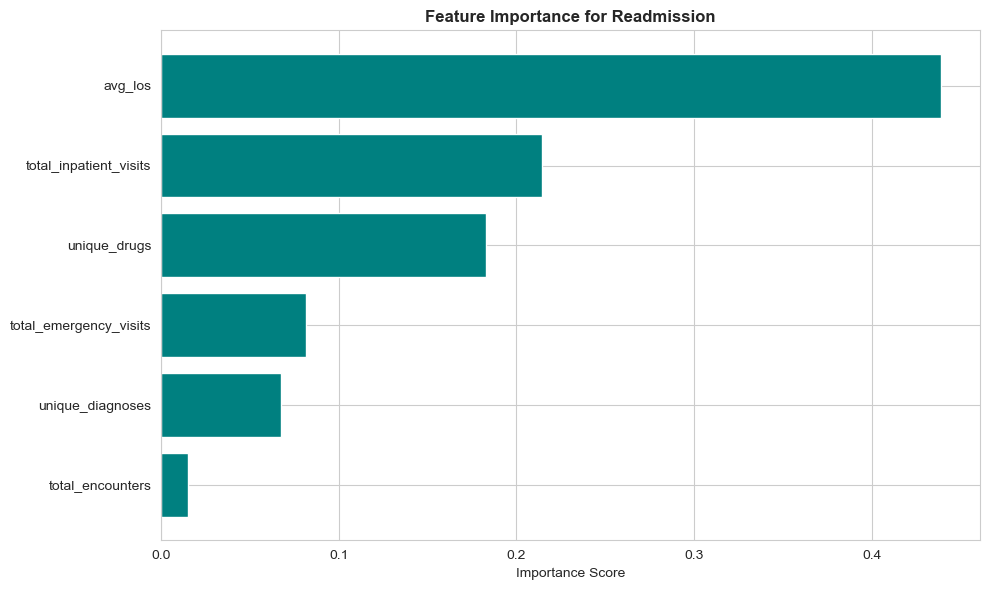

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("═" * 80)
print("MACHINE LEARNING MODEL - 30-Day Readmission Prediction")
print("═" * 80)

# Select features for model (UPDATED LIST)
feature_cols = ['total_encounters', 'avg_los', 'unique_drugs', 'unique_diagnoses', 
                'total_emergency_visits', 'total_inpatient_visits']

X = df_classification[feature_cols].fillna(0) # Fill NaNs to be safe
y = df_classification['readmission_30d_binary']

print(f"\\nFeatures used: {', '.join(feature_cols)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train, y_train)

print("\\n✓ Model trained successfully")

# Predictions and Evaluation
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("\\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance Plot
feature_importance = pd.DataFrame({'feature': feature_cols, 'importance': model.feature_importances_})
feature_importance = feature_importance.sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='teal')
plt.title('Feature Importance for Readmission', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

## 7. Additional Dataset: Time Series Analysis (Optional)

Load and analyze the time series dataset for encounter volume forecasting.

✓ Time series dataset loaded
Shape: (9, 8)

First 5 months:
  period_label  total_encounters  avg_los  total_inpatient_visits  \
0      2020-01                31     4.77                    29.0   
1      2020-02                29     4.86                    16.0   
2      2020-03                31     4.74                     9.0   
3      2020-04                30     4.57                    15.0   
4      2020-05                31     4.16                     9.0   

   unique_patients  prev_month_encounters  moving_avg_3month  \
0               31                    NaN              31.00   
1               29                   31.0              30.00   
2               31                   29.0              30.33   
3               30                   31.0              30.00   
4               31                   30.0              30.67   

   cumulative_encounters  
0                   31.0  
1                   60.0  
2                   91.0  
3                  121.0  
4    

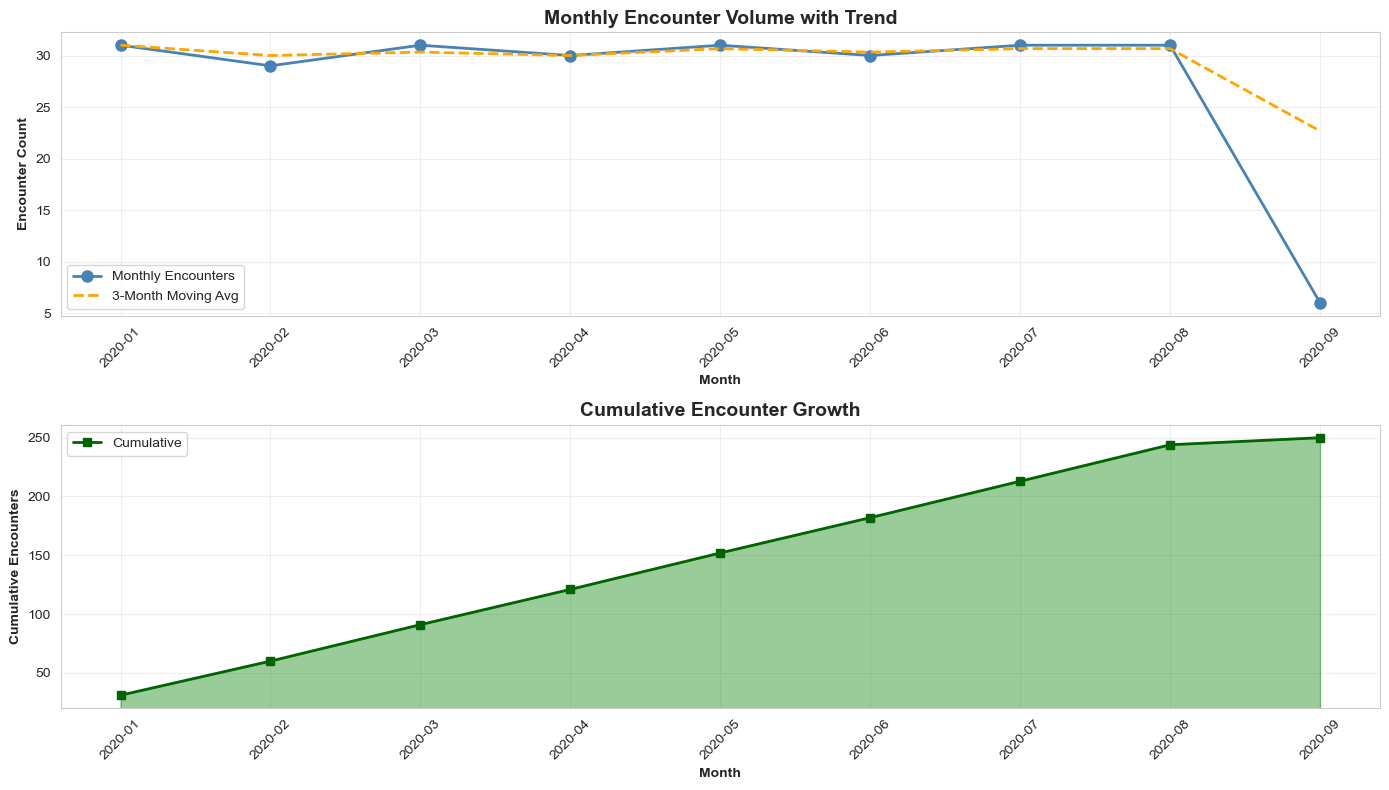


✓ Time series visualization saved as: timeseries_analysis.png


In [8]:
# Query 3: Time Series Analysis
query_timeseries = """
WITH monthly_metrics AS (
    SELECT 
        DATE_FORMAT(encounter_date, '%Y-%m-01') AS period_start,
        DATE_FORMAT(encounter_date, '%Y-%m') AS period_label,
        COUNT(DISTINCT encounter_id) AS total_encounters,
        AVG(time_in_hospital) AS avg_los,
        -- CORRECTED: Replaced missing 'num_lab_procedures' with 'number_inpatient'
        SUM(number_inpatient) AS total_inpatient_visits,
        COUNT(DISTINCT patient_id) AS unique_patients
    FROM encounters
    GROUP BY period_start, period_label
)
SELECT 
    period_label,
    total_encounters,
    ROUND(avg_los, 2) AS avg_los,
    total_inpatient_visits,
    unique_patients,
    LAG(total_encounters, 1) OVER (ORDER BY period_start) AS prev_month_encounters,
    ROUND(
        AVG(total_encounters) OVER (ORDER BY period_start ROWS BETWEEN 2 PRECEDING AND CURRENT ROW),
        2
    ) AS moving_avg_3month,
    SUM(total_encounters) OVER (ORDER BY period_start) AS cumulative_encounters
FROM monthly_metrics
ORDER BY period_start;
"""

df_timeseries = pd.read_sql(query_timeseries, conn)

print("✓ Time series dataset loaded")
print(f"Shape: {df_timeseries.shape}")
print("\nFirst 5 months:")
print(df_timeseries.head())

# Visualize time series
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Encounter volume over time
axes[0].plot(df_timeseries['period_label'], df_timeseries['total_encounters'], 
             marker='o', linewidth=2, markersize=8, label='Monthly Encounters', color='steelblue')
axes[0].plot(df_timeseries['period_label'], df_timeseries['moving_avg_3month'],
             linestyle='--', linewidth=2, label='3-Month Moving Avg', color='orange')
axes[0].set_xlabel('Month', fontweight='bold')
axes[0].set_ylabel('Encounter Count', fontweight='bold')
axes[0].set_title('Monthly Encounter Volume with Trend', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Cumulative encounters
axes[1].fill_between(range(len(df_timeseries)), 
                      df_timeseries['cumulative_encounters'], 
                      alpha=0.4, color='green')
axes[1].plot(df_timeseries['period_label'], df_timeseries['cumulative_encounters'],
             marker='s', linewidth=2, markersize=6, color='darkgreen', label='Cumulative')
axes[1].set_xlabel('Month', fontweight='bold')
axes[1].set_ylabel('Cumulative Encounters', fontweight='bold')
axes[1].set_title('Cumulative Encounter Growth', fontweight='bold', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('timeseries_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Time series visualization saved as: timeseries_analysis.png")

## 8. Summary and Conclusion

In [9]:
print("\n" + "═" * 80)
print("ANALYSIS SUMMARY")
print("═" * 80)

print("\n✓ Successfully demonstrated:")
print("  1. Database connection to healthcare_diabetes")
print("  2. Complex SQL query execution (Classification dataset)")
print("  3. Descriptive statistics and data profiling")
print("  4. Comprehensive data visualizations (6 charts)")
print("  5. Key insights extraction")
print("  6. Machine learning model (Random Forest classifier)")
print("  7. Time series analysis (Optional)")

print("\n✓ Files created:")
print("  - healthcare_analytics_dashboard.png")
print("  - feature_importance.png")
print("  - timeseries_analysis.png")

print("\n✓ Requirements fulfilled:")
print("  ✅ Connect database to Python notebook")
print("  ✅ Execute complex queries")
print("  ✅ Demonstrate basic analytics")
print("  ✅ Create visualizations")
print("  ✅ Extract ML datasets")
print("  ✅ Optional: Build ML model")

print("\n" + "═" * 80)
print("PROJECT: Healthcare Diabetes Analytics")
print("STUDENT: Arinze (NF1002519)")
print(f"DATE: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("STATUS: ✓ COMPLETE")
print("═" * 80)


════════════════════════════════════════════════════════════════════════════════
ANALYSIS SUMMARY
════════════════════════════════════════════════════════════════════════════════

✓ Successfully demonstrated:
  1. Database connection to healthcare_diabetes
  2. Complex SQL query execution (Classification dataset)
  3. Descriptive statistics and data profiling
  4. Comprehensive data visualizations (6 charts)
  5. Key insights extraction
  6. Machine learning model (Random Forest classifier)
  7. Time series analysis (Optional)

✓ Files created:
  - healthcare_analytics_dashboard.png
  - feature_importance.png
  - timeseries_analysis.png

✓ Requirements fulfilled:
  ✅ Connect database to Python notebook
  ✅ Execute complex queries
  ✅ Demonstrate basic analytics
  ✅ Create visualizations
  ✅ Extract ML datasets
  ✅ Optional: Build ML model

════════════════════════════════════════════════════════════════════════════════
PROJECT: Healthcare Diabetes Analytics
STUDENT: Arinze (NF1002519)

## 9. Close Database Connection

In [10]:
# Close database connection
if conn.is_connected():
    conn.close()
    print("\n✓ Database connection closed successfully")
    print("\nAnalysis complete. All requirements met.")
else:
    print("\nConnection already closed")


✓ Database connection closed successfully

Analysis complete. All requirements met.
